## Neuro Representation Learning with AraBERT

A pretrained transformer encoder (AraBERT) is employed to capture
deep contextual semantic representations of Arabic sequences.

The model pipeline includes:

1. Transformer sequence encoding
2. Extraction of the [CLS] contextual embedding
3. Dropout regularization layer
4. Sigmoid classification head for binary simile prediction

Binary cross-entropy loss and Adam optimization are used for training.

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from transformers import DataCollatorWithPadding
from arabert.preprocess import ArabertPreprocessor
from transformers import TFAutoModel
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

In [11]:
from symbolic_model import build_symbolic_matrix


In [12]:
ModelName = "aubmindlab/bert-large-arabertv02"
MAX_LEN = 120
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42


tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
# import pandas as pd

# df = pd.read_csv("cleaned_cleaned_")

# sentences = df["sentence"].tolist()
# labels = df["label"].tolist()

In [13]:
train_df = pd.read_csv("/Users/roamsaleh/Downloads/similedata/cleaned_train.csv")
val_df   = pd.read_csv("/Users/roamsaleh/Downloads/similedata/cleaned_validation.csv")
test_df  = pd.read_csv("/Users/roamsaleh/Downloads/similedata/cleaned_test.csv")

In [14]:
X_train = train_df["text"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label"].tolist()

In [15]:
print(len(X_train), len(X_val), len(X_test))

6000 1108 3000


In [16]:
# X_train_val, X_test, y_train_val, y_test = train_test_split(sentences, labels, test_size=0.1, random_state=SEED)
# X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=SEED)
X_train_sym = build_symbolic_matrix(X_train)
X_val_sym = build_symbolic_matrix(X_val)
X_test_sym = build_symbolic_matrix(X_test)
arabert_prep = ArabertPreprocessor(model_name=ModelName)
tokenizer = AutoTokenizer.from_pretrained(ModelName)

def PreprocessTexts(texts):
    texts = [arabert_prep.preprocess(text) for text in texts]
    encodings = tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return encodings['input_ids'], encodings['attention_mask']

X_train_ids, X_train_mask =PreprocessTexts(X_train)
X_val_ids, X_val_mask =PreprocessTexts(X_val)
X_test_ids, X_test_mask =PreprocessTexts(X_test)

In [17]:
def create_arabert_model(model_name, max_len):

    word_inputs = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")
    sym_input = tf.keras.Input(shape=(11,), dtype=tf.float32, name="symbolic_features")

    arabert = TFAutoModel.from_pretrained(model_name, from_pt=True)
    outputs = arabert(word_inputs, attention_mask=attention_mask)[0]

    # cls = outputs[:, 0, :]
    # sym_proj = tf.keras.layers.Dense(32, activation='relu')(sym_input)
    # combined = tf.keras.layers.Concatenate()([cls, sym_proj])

    # x = tf.keras.layers.Dense(256, activation='relu')(combined)
    cls = outputs[:, 0, :]
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(cls)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    bert_prob = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    has_structure = sym_input[:, 0:1]
    confidence = sym_input[:, 2:3]
    symbolic_score = has_structure * confidence
    alpha = 0.7
    final_output = alpha * bert_prob + (1 - alpha) * symbolic_score

    model = tf.keras.Model(
        inputs=[word_inputs, attention_mask, sym_input],
        outputs=final_output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = create_arabert_model(ModelName, MAX_LEN)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)
history = model.fit(
    {
        "input_ids": X_train_ids,
        "attention_mask": X_train_mask,
        "symbolic_features": X_train_sym
    },
    np.array(y_train),
    validation_data=(
        {
            "input_ids": X_val_ids,
            "attention_mask": X_val_mask,
            "symbolic_features": X_val_sym
        },
        np.array(y_val)
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)
y_val_pred_prob = model.predict({
    "input_ids": X_val_ids,
    "attention_mask": X_val_mask,
    "symbolic_features": X_val_sym
})

y_val_pred = (y_val_pred_prob > 0.5).astype(int)

print("Validation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))



Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.bias', 'cls.predictions.bias', 'bert.embeddings.position_ids', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the 

Epoch 1/10


375/375 [==============================] - 3130s 8s/step - loss: 4.4430 - accuracy: 0.7870 - val_loss: 4.1230 - val_accuracy: 0.9332
Epoch 2/10
375/375 [==============================] - 3159s 8s/step - loss: 4.0471 - accuracy: 0.9297 - val_loss: 3.8768 - val_accuracy: 0.9513
Epoch 3/10
375/375 [==============================] - 3102s 8s/step - loss: 3.7927 - accuracy: 0.9455 - val_loss: 3.6409 - val_accuracy: 0.9639
Epoch 4/10
375/375 [==============================] - 3187s 8s/step - loss: 3.5543 - accuracy: 0.9490 - val_loss: 3.4046 - val_accuracy: 0.9666
Epoch 5/10
375/375 [==============================] - 3100s 8s/step - loss: 3.3131 - accuracy: 0.9562 - val_loss: 3.1772 - val_accuracy: 0.9657
Epoch 6/10
375/375 [==============================] - 3122s 8s/step - loss: 3.0825 - accuracy: 0.9545 - val_loss: 2.9555 - val_accuracy: 0.9639
Epoch 7/10
375/375 [==============================] - 3171s 8s/step - loss: 2.8878 - accuracy: 0.9350 - val_loss: 2.8533 - val_accuracy: 0.8574
Epo

In [19]:
y_pred_prob = model.predict({
    "input_ids": X_test_ids,
    "attention_mask": X_test_mask,
    "symbolic_features": X_test_sym
})

y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

94/94 [==============================] - 414s 4s/step
[[1423   55]
 [  49 1473]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1478
           1       0.96      0.97      0.97      1522

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



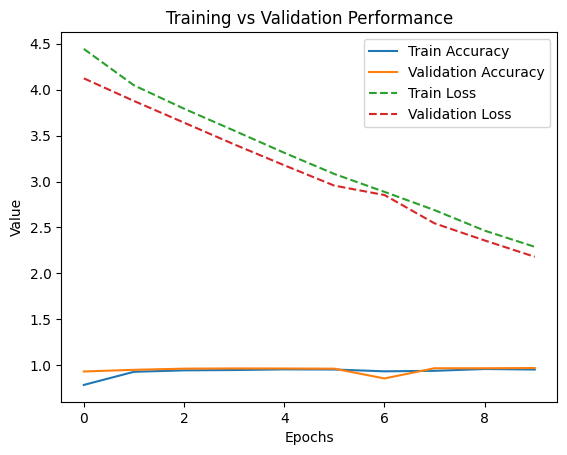

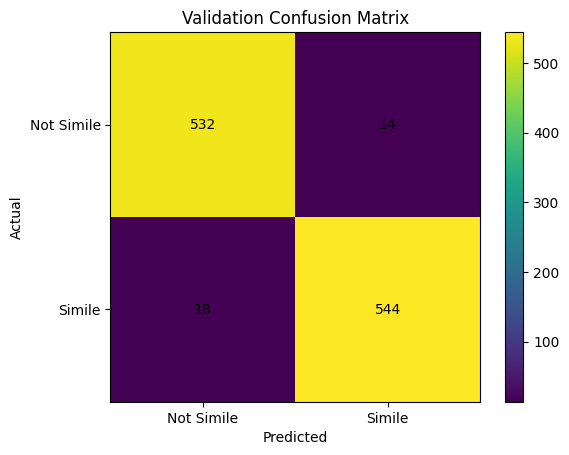

In [20]:
plt.figure()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Loss
plt.plot(history.history['loss'], linestyle='--', label='Train Loss')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training vs Validation Performance")
plt.legend()
plt.show()

cm = confusion_matrix(y_val, y_val_pred)

plt.figure()
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.colorbar()

classes = ["Not Simile", "Simile"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [21]:
model.save("arabert_simile_model")

INFO:tensorflow:Assets written to: arabert_simile_model/assets


INFO:tensorflow:Assets written to: arabert_simile_model/assets
